In [122]:

import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Getting data 


In [124]:
ALL_Data =  pd.read_csv("All_features.csv",index_col="Date",parse_dates=["Date"]).dropna()
ALL_Data

,HDFCBANK,NIFTY50,BANKNIFTY,SENSEX,INDIA_VIX,USDINR,SP500,NASDAQ100,DOWJONES,NIKKEI225,HANGSENG,GOLD,BRENT_OIL,ICICIBANK,SBIN,AXISBANK,KOTAKBANK
Date,,,,,,,,,,,,,,,,,
2015-01-05,500.999146,53.110001,1203.900024,218.399033,302.995667,63.278000,125.738350,273.830566,27842.320312,17501.650391,2020.579956,23721.320312,14.150000,17408.710938,4160.959961,19017.179688,8378.400391
2015-01-06,483.090759,51.099998,1219.300049,214.999222,290.143066,63.338001,124.239151,262.579651,26987.460938,17371.640625,2002.609985,23485.410156,17.420000,16883.189453,4110.830078,18430.535156,8127.350098
2015-01-07,482.703583,51.150002,1210.599976,215.626694,282.297943,63.568001,126.239731,262.798523,26908.820312,17584.519531,2025.900024,23681.259766,18.139999,16885.330078,4160.000000,18304.037109,8102.100098
2015-01-08,485.898041,50.959999,1208.400024,220.155975,289.976135,63.272999,133.105209,266.913666,27274.710938,17907.869141,2062.139893,23835.529297,16.469999,17167.099609,4240.549805,18701.183594,8234.599609
2015-01-09,479.121918,50.110001,1216.000000,222.620316,285.302460,62.667999,135.120667,265.468964,27458.380859,17737.369141,2044.810059,23919.949219,15.960000,17197.730469,4213.279785,18637.033203,8284.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,1233.199951,62.070000,4444.600098,987.700012,1368.500000,89.570000,429.940002,957.049133,85567.476562,48362.679688,6878.490234,25801.769531,9.680000,50402.390625,25461.699219,59304.000000,26172.400391
2025-12-23,1225.000000,62.380001,4482.799805,996.599976,1363.000000,89.603897,432.540009,954.691650,85524.843750,48442.410156,6909.790039,25774.140625,9.380000,50412.871094,25587.830078,59299.550781,26177.150391
2025-12-24,1226.300049,62.240002,4480.600098,997.200012,1359.800049,89.507896,432.739990,951.793884,85408.703125,48731.160156,6932.049805,25818.929688,9.190000,50344.101562,25656.150391,59183.601562,26142.099609


# CHEking Stationery 

In [126]:
# result_return = adfuller(HDFC_PRICE['Log_Return'])
# print("\n--- ADF Test on Log Returns ---")
# print("p-value:", round(result_return[1], 6))
# if result_return[1] < 0.05:
#     print("RESULT: Stationary - safe to use in regression")
# else:
#     print("RESULT: Non-stationary - problem!")

In [127]:
for i in ALL_Data.columns:
    result = adfuller(ALL_Data[i])[1]
    if result > 0.05:
        print (f"Asset {i} is 'NOT STATIONRY'")
    else:
         print (f"Asset {i} is 'STATIONRY'")

    


Asset HDFCBANK is 'NOT STATIONRY'
Asset NIFTY50 is 'NOT STATIONRY'
Asset BANKNIFTY is 'NOT STATIONRY'
Asset SENSEX is 'NOT STATIONRY'
Asset INDIA_VIX is 'NOT STATIONRY'
Asset USDINR is 'NOT STATIONRY'
Asset SP500 is 'NOT STATIONRY'
Asset NASDAQ100 is 'NOT STATIONRY'
Asset DOWJONES is 'NOT STATIONRY'
Asset NIKKEI225 is 'NOT STATIONRY'
Asset HANGSENG is 'NOT STATIONRY'
Asset GOLD is 'NOT STATIONRY'
Asset BRENT_OIL is 'STATIONRY'
Asset ICICIBANK is 'NOT STATIONRY'
Asset SBIN is 'NOT STATIONRY'
Asset AXISBANK is 'NOT STATIONRY'
Asset KOTAKBANK is 'NOT STATIONRY'


## Hence most of the featutre are non stationry we need to convert ot stationry 

# Making Sationry using log pct change 

In [130]:
log_ALL_Data= np.log(ALL_Data/ALL_Data.shift()).dropna()

In [131]:
log_ALL_Data

,HDFCBANK,NIFTY50,BANKNIFTY,SENSEX,INDIA_VIX,USDINR,SP500,NASDAQ100,DOWJONES,NIKKEI225,HANGSENG,GOLD,BRENT_OIL,ICICIBANK,SBIN,AXISBANK,KOTAKBANK
Date,,,,,,,,,,,,,,,,,
2015-01-06,-0.036400,-0.038581,0.012711,-0.015689,-0.043344,0.000948,-0.011995,-0.041955,-0.031185,-0.007456,-0.008933,-0.009995,0.207904,-0.030652,-0.012121,-0.031334,-0.030422
2015-01-07,-0.000802,0.000978,-0.007161,0.002914,-0.027411,0.003625,0.015974,0.000833,-0.002918,0.012180,0.011563,0.008305,0.040500,0.000127,0.011890,-0.006887,-0.003112
2015-01-08,0.006596,-0.003722,-0.001819,0.020788,0.026836,-0.004652,0.052957,0.015538,0.013506,0.018221,0.017730,0.006493,-0.096579,0.016550,0.019178,0.021465,0.016221
2015-01-09,-0.014044,-0.016820,0.006270,0.011131,-0.016249,-0.009608,0.015028,-0.005427,0.006712,-0.009567,-0.008439,0.003536,-0.031455,0.001783,-0.006452,-0.003436,0.006042
2015-01-13,0.019111,-0.072835,0.014937,-0.012687,-0.002783,-0.009620,0.023241,0.006247,-0.001190,-0.006998,-0.010709,0.012300,0.032062,-0.006418,-0.011237,0.003746,0.001797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,0.002111,0.026115,0.018897,0.002230,0.010578,-0.007627,-0.004548,-0.006139,0.007485,0.004721,0.006416,0.004321,0.016667,0.017920,0.004547,0.003967,0.007902
2025-12-23,-0.006672,0.004982,0.008558,0.008970,-0.004027,0.000378,0.006029,-0.002466,-0.000498,0.001647,0.004540,-0.001071,-0.031482,0.000208,0.004942,-0.000075,0.000181
2025-12-24,0.001061,-0.002247,-0.000491,0.000602,-0.002350,-0.001072,0.000462,-0.003040,-0.001359,0.005943,0.003216,0.001736,-0.020464,-0.001365,0.002666,-0.001957,-0.001340


# Recheking Stationery 

In [133]:
for i in log_ALL_Data.columns:
    result = adfuller(log_ALL_Data[i])[1]
    if result > 0.05:
        print (f"Asset {i} is 'NOT STATIONRY'")
    else:
         print (f"Asset {i} is 'STATIONRY'")


Asset HDFCBANK is 'STATIONRY'
Asset NIFTY50 is 'STATIONRY'
Asset BANKNIFTY is 'STATIONRY'
Asset SENSEX is 'STATIONRY'
Asset INDIA_VIX is 'STATIONRY'
Asset USDINR is 'STATIONRY'
Asset SP500 is 'STATIONRY'
Asset NASDAQ100 is 'STATIONRY'
Asset DOWJONES is 'STATIONRY'
Asset NIKKEI225 is 'STATIONRY'
Asset HANGSENG is 'STATIONRY'
Asset GOLD is 'STATIONRY'
Asset BRENT_OIL is 'STATIONRY'
Asset ICICIBANK is 'STATIONRY'
Asset SBIN is 'STATIONRY'
Asset AXISBANK is 'STATIONRY'
Asset KOTAKBANK is 'STATIONRY'


## We have convert successfully all data STATIONRY

## We are now doing feature enginnering part 

In [136]:
log_ALL_Data["HDFC_log_return_lagged"]  = log_ALL_Data["HDFCBANK"].shift(1)
log_ALL_Data["HDFC_log_return_Lag5"]    = log_ALL_Data["HDFCBANK"].shift(5)
log_ALL_Data["HDFC_log_return_Lag10"]   = log_ALL_Data["HDFCBANK"].shift(10)

# SMA features - keeping only 3 (short, medium, long term)
# Removed SMA20 and SMA100 - too similar to SMA10/SMA50/SMA200
log_ALL_Data["HDFC_log_return_SMA10"]  = log_ALL_Data["HDFC_log_return_lagged"].rolling(10).mean()
log_ALL_Data["HDFC_log_return_SMA50"]  = log_ALL_Data["HDFC_log_return_lagged"].rolling(50).mean()
log_ALL_Data["HDFC_log_return_SMA200"] = log_ALL_Data["HDFC_log_return_lagged"].rolling(200).mean()

# EMA features - keeping only 3 (short, medium, long term)
# Removed EMA20 and EMA100 - too similar to EMA10/EMA50/EMA200
log_ALL_Data["HDFC_log_return_10_EMA"]  = log_ALL_Data["HDFC_log_return_lagged"].ewm(span=10).mean()
log_ALL_Data["HDFC_log_return_50_EMA"]  = log_ALL_Data["HDFC_log_return_lagged"].ewm(span=50).mean()
log_ALL_Data["HDFC_log_return_200_EMA"] = log_ALL_Data["HDFC_log_return_lagged"].ewm(span=200).mean()

# Momentum - rolling SUM of last 10 returns (not pct_change)
# WHY: sum of log returns = total return over that period
# pct_change on log returns was double transforming
log_ALL_Data["momentum10"] = log_ALL_Data["HDFC_log_return_lagged"].rolling(10).sum()

In [137]:
log_ALL_Data.dropna(inplace = True)
log_ALL_Data

,HDFCBANK,NIFTY50,BANKNIFTY,SENSEX,INDIA_VIX,USDINR,SP500,NASDAQ100,DOWJONES,NIKKEI225,...,HDFC_log_return_lagged,HDFC_log_return_Lag5,HDFC_log_return_Lag10,HDFC_log_return_SMA10,HDFC_log_return_SMA50,HDFC_log_return_SMA200,HDFC_log_return_10_EMA,HDFC_log_return_50_EMA,HDFC_log_return_200_EMA,momentum10
Date,,,,,,,,,,,,,,,,,,,,,
2015-12-11,-0.020886,-0.046364,0.003535,-0.013527,-0.037978,-0.001556,-0.015161,-0.020251,-0.008267,-0.017770,...,-0.001444,-0.004334,0.015297,-0.003042,-0.001037,-0.000660,-0.004397,-0.002846,-0.001629,-0.030425
2015-12-14,-0.021331,-0.000264,-0.011394,0.008280,-0.001204,0.005301,0.009540,-0.005957,0.004220,0.005965,...,-0.020886,0.003901,-0.005002,-0.006661,-0.001969,-0.000582,-0.007395,-0.003554,-0.001850,-0.066607
2015-12-15,0.010952,0.013880,-0.001692,0.004162,-0.010497,-0.001043,0.018373,0.001989,0.006740,0.008965,...,-0.021331,-0.007600,-0.015157,-0.008294,-0.002245,-0.000685,-0.009929,-0.004251,-0.002073,-0.082936
2015-12-16,0.004690,-0.033319,0.014106,0.007382,0.022671,-0.002508,0.011440,0.003968,0.006846,0.012711,...,0.010952,-0.018034,-0.004560,-0.005683,-0.001970,-0.000663,-0.006132,-0.003655,-0.001924,-0.056827
2015-12-17,-0.005952,-0.000269,-0.025556,0.012060,0.004355,-0.007125,0.012449,0.015714,0.012063,-0.014371,...,0.004690,-0.001444,0.006508,-0.004758,-0.002488,-0.000569,-0.004165,-0.003328,-0.001848,-0.047578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,0.002111,0.026115,0.018897,0.002230,0.010578,-0.007627,-0.004548,-0.006139,0.007485,0.004721,...,0.000650,-0.001011,-0.006807,-0.004131,0.001285,0.000855,-0.003375,0.000062,0.000570,-0.041309
2025-12-23,-0.006672,0.004982,0.008558,0.008970,-0.004027,0.000378,0.006029,-0.002466,-0.000498,0.001647,...,0.002111,-0.052080,0.001647,-0.003239,0.001709,0.001097,-0.002378,0.000143,0.000586,-0.032392
2025-12-24,0.001061,-0.002247,-0.000491,0.000602,-0.002350,-0.001072,0.000462,-0.003040,-0.001359,0.005943,...,-0.006672,0.004173,0.002114,-0.004071,0.001586,0.001170,-0.003159,-0.000125,0.000514,-0.040711


In [138]:
window = 14

delta = ALL_Data['HDFCBANK'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()

rs = avg_gain / avg_loss

log_ALL_Data['RSI'] = 100 - (100 / (1 + rs))

In [139]:
ALL_Data_HDFC =  pd.read_csv("new_HDFC_ALL.csv",index_col="Date",parse_dates=["Date"]).dropna()
ALL_Data_HDFC

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,217.235336,217.771559,215.638102,216.995754,3544940
2015-01-02,220.258682,221.171388,216.858862,216.858862,5900384
2015-01-05,218.399017,221.456572,217.931245,221.331078,4796000
2015-01-06,214.999252,218.262173,213.926820,217.680326,8219680
2015-01-07,215.626709,217.075624,213.630165,214.417377,5746112
...,...,...,...,...,...
2025-12-23,996.599976,998.900024,987.700012,990.500000,17927849
2025-12-24,997.200012,999.400024,993.000000,993.000000,13699996
2025-12-26,992.099976,997.200012,987.700012,996.000000,9360853


In [140]:
high_low = ALL_Data_HDFC['High'] - ALL_Data_HDFC['Low']
high_close = (ALL_Data_HDFC['High'] - ALL_Data_HDFC['Close'].shift(1)).abs()
low_close = (ALL_Data_HDFC['Low'] - ALL_Data_HDFC['Close'].shift(1)).abs()

tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)

log_ALL_Data['ATR'] = tr.rolling(window=14).mean()

In [141]:
log_ALL_Data.dropna(inplace =True)

In [142]:
log_ALL_Data.columns

Index(['HDFCBANK', 'NIFTY50', 'BANKNIFTY', 'SENSEX', 'INDIA_VIX', 'USDINR',
       'SP500', 'NASDAQ100', 'DOWJONES', 'NIKKEI225', 'HANGSENG', 'GOLD',
       'BRENT_OIL', 'ICICIBANK', 'SBIN', 'AXISBANK', 'KOTAKBANK',
       'HDFC_log_return_lagged', 'HDFC_log_return_Lag5',
       'HDFC_log_return_Lag10', 'HDFC_log_return_SMA10',
       'HDFC_log_return_SMA50', 'HDFC_log_return_SMA200',
       'HDFC_log_return_10_EMA', 'HDFC_log_return_50_EMA',
       'HDFC_log_return_200_EMA', 'momentum10', 'RSI', 'ATR'],
      dtype='object')

# Checking multicolinerty of features 


In [144]:
len(log_ALL_Data.columns)

29

In [145]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define our X features (inputs)
# We exclude HDFC_Close, Log_Return, and HDFC_Target
# HDFC_Close = raw price, not a feature
# Log_Return = current day return, would be leakage
# HDFC_Target = this is Y (what we predict), not an input

X = log_ALL_Data[[
    'NIFTY50', 'BANKNIFTY', 'SENSEX', 'INDIA_VIX', 'USDINR',
       'SP500', 'NASDAQ100', 'DOWJONES', 'NIKKEI225', 'HANGSENG', 'GOLD',
       'BRENT_OIL', 'ICICIBANK', 'SBIN', 'AXISBANK', 'KOTAKBANK',
       'HDFC_log_return_lagged', 'HDFC_log_return_Lag5',
       'HDFC_log_return_Lag10', 'HDFC_log_return_SMA10',
       'HDFC_log_return_SMA50', 'HDFC_log_return_SMA200',
       'HDFC_log_return_10_EMA', 'HDFC_log_return_50_EMA',
       'HDFC_log_return_200_EMA', 'momentum10', 'RSI', 'ATR'
]]

Y = log_ALL_Data['HDFCBANK']

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Sort by VIF so worst offenders show at top
vif_data = vif_data.sort_values('VIF', ascending=False)

print("=== VIF SCORES ===")
print(vif_data.to_string(index=False))

print("\n=== FEATURES TO DROP (VIF > 10) ===")
to_drop = vif_data[vif_data['VIF'] > 10]
if len(to_drop) == 0:
    print("None - all features are fine")
else:
    print(to_drop['Feature'].tolist())

print("\n=== FEATURES TO KEEP (VIF < 10) ===")
to_keep = vif_data[vif_data['VIF'] <= 10]
print(to_keep['Feature'].tolist())

=== VIF SCORES ===
                Feature        VIF
             momentum10        inf
  HDFC_log_return_SMA10        inf
               DOWJONES 123.998901
              KOTAKBANK 119.775323
               HANGSENG  51.431327
               AXISBANK  23.081090
 HDFC_log_return_50_EMA  22.160505
              NIKKEI225  19.027087
HDFC_log_return_200_EMA  14.927781
                   SBIN  14.507209
 HDFC_log_return_10_EMA  10.653413
  HDFC_log_return_SMA50   6.970593
                    RSI   5.864527
                    ATR   5.333548
 HDFC_log_return_SMA200   5.096154
              INDIA_VIX   5.024782
                 SENSEX   4.660775
              NASDAQ100   3.234077
                  SP500   2.328531
 HDFC_log_return_lagged   2.103610
              BRENT_OIL   1.565720
                   GOLD   1.458361
              ICICIBANK   1.441933
  HDFC_log_return_Lag10   1.368484
   HDFC_log_return_Lag5   1.174540
                NIFTY50   1.143891
                 USDINR   1.102650
 

## new data frmae after 1st multicolinerty check 

In [147]:
new_log_ALL_Data = pd.DataFrame()

for i in to_keep['Feature']:
    new_log_ALL_Data[i] = log_ALL_Data[i]

In [148]:
new_log_ALL_Data["HDFCBANK"] = log_ALL_Data['HDFCBANK']

In [149]:
X = new_log_ALL_Data[[
    'NIFTY50', 'BANKNIFTY', 'SENSEX', 'INDIA_VIX', 'USDINR',
       'SP500', 'NASDAQ100', 'GOLD', 'BRENT_OIL', 'ICICIBANK',
       'HDFC_log_return_lagged', 'HDFC_log_return_Lag5',
       'HDFC_log_return_Lag10', 'HDFC_log_return_SMA50',
       'HDFC_log_return_SMA200', 'RSI', 'ATR'
]]

Y = new_log_ALL_Data['HDFCBANK']

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Sort by VIF so worst offenders show at top
vif_data = vif_data.sort_values('VIF', ascending=False)

print("=== VIF SCORES ===")
print(vif_data.to_string(index=False))

print("\n=== FEATURES TO DROP (VIF > 10) ===")
to_drop = vif_data[vif_data['VIF'] > 10]
if len(to_drop) == 0:
    print("None - all features are fine")
else:
    print(to_drop['Feature'].tolist())

print("\n=== FEATURES TO KEEP (VIF < 10) ===")
to_keep = vif_data[vif_data['VIF'] <= 10]
print(to_keep['Feature'].tolist())

=== VIF SCORES ===
               Feature      VIF
                   RSI 4.596424
                   ATR 4.178386
             INDIA_VIX 2.066192
             NASDAQ100 1.864460
                SENSEX 1.758950
                 SP500 1.574097
 HDFC_log_return_SMA50 1.444602
                  GOLD 1.425593
             ICICIBANK 1.387998
             BRENT_OIL 1.351837
HDFC_log_return_SMA200 1.301622
                USDINR 1.090197
HDFC_log_return_lagged 1.082911
 HDFC_log_return_Lag10 1.060514
               NIFTY50 1.052236
  HDFC_log_return_Lag5 1.045483
             BANKNIFTY 1.037034

=== FEATURES TO DROP (VIF > 10) ===
None - all features are fine

=== FEATURES TO KEEP (VIF < 10) ===
['RSI', 'ATR', 'INDIA_VIX', 'NASDAQ100', 'SENSEX', 'SP500', 'HDFC_log_return_SMA50', 'GOLD', 'ICICIBANK', 'BRENT_OIL', 'HDFC_log_return_SMA200', 'USDINR', 'HDFC_log_return_lagged', 'HDFC_log_return_Lag10', 'NIFTY50', 'HDFC_log_return_Lag5', 'BANKNIFTY']


## Final feature we got whihc are uncorelated with each other 

In [151]:
len(new_log_ALL_Data.columns)

18

# Lasso regression runnning to get final model 

In [153]:
X = new_log_ALL_Data.drop(columns=['HDFCBANK'])
y = new_log_ALL_Data['HDFCBANK']

# Split first before anything else
# 80% train, 20% test, chronological order
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train end date:", X_train.index.max().date())
print("Test start date:", X_test.index.min().date())

# why we do Now the scaler computes the mean and standard deviation using all data, including the future test observations.

# Thus the training data indirectly gets information about the test period.

# This is called data leakage, and it makes your model evaluation overly optimistic.

Train rows: 1712
Test rows: 429
Train end date: 2023-12-19
Test start date: 2023-12-20


In [154]:
# Fit scaler ONLY on training data
# WHY: scaler must not see test data at all
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # only transform on test

In [155]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# TimeSeriesSplit ensures each fold respects time order
# No future data leaks into past training folds
tscv = TimeSeriesSplit(n_splits=5)

lasso = LassoCV(cv=tscv)
lasso.fit(X_train_scaled, y_train)  # fit on train only, not full data

LassoCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None))

In [156]:
import pandas as pd

coef = pd.Series(lasso.coef_, index=X.columns)
coef

HDFC_log_return_SMA50    -0.001064
RSI                       0.003381
ATR                      -0.000000
HDFC_log_return_SMA200   -0.000185
INDIA_VIX                 0.010619
SENSEX                    0.001812
NASDAQ100                 0.003613
SP500                     0.001766
HDFC_log_return_lagged    0.000000
BRENT_OIL                -0.000811
GOLD                      0.000358
ICICIBANK                -0.000000
HDFC_log_return_Lag10    -0.000618
HDFC_log_return_Lag5     -0.000612
NIFTY50                  -0.001284
USDINR                   -0.000000
BANKNIFTY                -0.000000
dtype: float64

In [157]:
selected_features = coef[abs(coef) > 0.001].index

In [158]:
X_final = X[selected_features]

In [159]:
len(X_final.columns)

7

In [160]:
X_final

,HDFC_log_return_SMA50,RSI,INDIA_VIX,SENSEX,NASDAQ100,SP500,NIFTY50
Date,,,,,,,
2015-12-11,-0.001037,29.105854,-0.037978,-0.013527,-0.020251,-0.015161,-0.046364
2015-12-14,-0.001969,25.078653,-0.001204,0.008280,-0.005957,0.009540,-0.000264
2015-12-15,-0.002245,31.772836,-0.010497,0.004162,0.001989,0.018373,0.013880
2015-12-16,-0.001970,29.667641,0.022671,0.007382,0.003968,0.011440,-0.033319
2015-12-17,-0.002488,19.778270,0.004355,0.012060,0.015714,0.012449,-0.000269
...,...,...,...,...,...,...,...
2025-12-22,0.001285,40.975231,0.010578,0.002230,-0.006139,-0.004548,0.026115
2025-12-23,0.001709,32.806627,-0.004027,0.008970,-0.002466,0.006029,0.004982
2025-12-24,0.001586,28.502805,-0.002350,0.000602,-0.003040,0.000462,-0.002247


# now divided train and test data 

In [162]:
# FINAL STEP: Proper test set evaluation
# Using the X_test and y_test from your correct split

import statsmodels.api as sm
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Get the final feature columns Lasso selected
final_cols = selected_features.tolist()

# Use the already split train/test from your correct split
X_train_final = X_train[final_cols]
X_test_final  = X_test[final_cols]

# Add lag 1 of each feature (same as what you did before)
for col in final_cols:
    X_train_final[f"{col}_Lag1"] = X_train_final[col].shift(1)
    X_test_final[f"{col}_Lag1"]  = X_test_final[col].shift(1)

# Drop NaN from lagging
X_train_final = X_train_final.dropna()
X_test_final  = X_test_final.dropna()

# Align y to match
y_train_final = y_train.loc[X_train_final.index]
y_test_final  = y_test.loc[X_test_final.index]

# Add constant for OLS
X_train_const = sm.add_constant(X_train_final)
X_test_const  = sm.add_constant(X_test_final)

# Train OLS model on train only
model = sm.OLS(y_train_final, X_train_const).fit()
print(model.summary())

# --- Predict on TEST set ---
#this out of sample test 
y_pred_test = model.predict(X_test_const)
# --- Test set metrics ---
r2   = r2_score(y_test_final, y_pred_test)
mse  = mean_squared_error(y_test_final, y_pred_test)
rmse = np.sqrt(mse)

print("\n=== TEST SET PERFORMANCE (honest metrics) ===")
print(f"R-squared : {r2:.4f}")
print(f"MSE       : {mse:.6f}")
print(f"RMSE      : {rmse:.6f}")

# --- Directional accuracy on TEST set ---
correct = (np.sign(y_test_final) == np.sign(y_pred_test)).mean()
print(f"Directional Accuracy on TEST: {correct:.2%}")
print("(Above 50% = model has some edge, below 50% = worse than random)")

                            OLS Regression Results                            
Dep. Variable:               HDFCBANK   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     198.0
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:10:16   Log-Likelihood:                 4810.1
No. Observations:                1711   AIC:                            -9590.
Df Residuals:                    1696   BIC:                            -9509.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

# to improve model we need to add higer ML like Random Forest, XGBoost, or LSTM  or Better features — FII/DII flow data, options data (Put-Call ratio), earnings surprise, news sentiment —

#  assumption testing 

# 1. Linearity test between error and Independent feature 

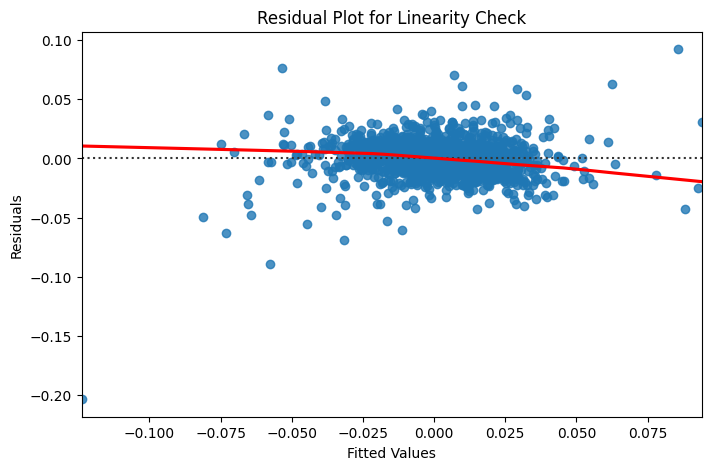

In [195]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.residplot(
    x=model.fittedvalues,
    y=model.resid,
    lowess=True,
    line_kws={'color':'red'}
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Linearity Check")
plt.show()

# 2. Durbin-Watson Test (Independence of Errors)

In [197]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(model.resid)

print("Durbin-Watson Statistic =", round(dw,4))

if 1.5 <= dw <= 2.5:
    print("No significant autocorrelation")
elif dw < 1.5:
    print("Positive autocorrelation present")
else:
    print("Negative autocorrelation present")

Durbin-Watson Statistic = 1.9101
No significant autocorrelation


# 3. Breusch-Pagan Test (Homoscedasticity)

In [205]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    model.resid,
    model.model.exog
)

labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

print(dict(zip(labels,bp_test)))
p_value = bp_test[1]

if p_value > 0.05:
    print("Homoscedasticity assumption satisfied")
else:
    print("Heteroscedasticity present")

{'LM Statistic': 197.5002770314494, 'LM p-value': 1.7790190512673569e-34, 'F Statistic': 15.808227436717365, 'F p-value': 8.92575075031915e-37}
Heteroscedasticity present


# 4. Jarque-Bera Test (Normality)

In [210]:
from scipy.stats import jarque_bera

jb_stat, jb_p = jarque_bera(model.resid)

print("Jarque-Bera Statistic =", jb_stat)
print("p-value =", jb_p)

if jb_p > 0.05:
    print("Residuals are normally distributed")
else:
    print("Residuals are not normally distributed")

Jarque-Bera Statistic = 48109.835266454575
p-value = 0.0
Residuals are not normally distributed
